# Bike Sharing Demand

## Raw Data -> Feature Engineering
In this Notebook you will find the data wrangling for the Seoul Bike Dataset. At then you will get two different datasets: 
Next feauture techniques were apply: 
 - For hour cyclical transformation
 - For 'Seasons' and 'Holiday' was used One Hot Encoding
 - New variable DayofWeek
 - Drop Columns like 'Functioning Day' and 'Dew point temperature(°C)'


---

### 1. LOAD AND CLEAN THE BASE DATA

In [25]:
# --- IMPORTS ---
import pandas as pd
import numpy as np
import os 
import matplotlib.pyplot as plt
import seaborn as sns



In [26]:
RESULTS_DIR = "data/raw"
df = pd.read_csv(f"{RESULTS_DIR}/SeoulBikeData.csv",encoding='latin1')

# Rename columns
df.columns = ['Date', 'Rented_Bike_Count', 'Hour', 'Temperature', 'Humidity', 
              'Wind_Speed', 'Visibility', 'Dew_Point', 'Solar_Radiation', 
              'Rainfall', 'Snowfall', 'Seasons', 'Holiday', 'Functioning_Day']

# Convert the text column into a true pandas Datetime object
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')

# Extract the exact Month (1-12)
df['Month'] = df['Date'].dt.month

# Extract the Day of the Week (0 = Monday, 6 = Sunday)
df['DayOfWeek'] = df['Date'].dt.dayofweek

# Now that you have the math-friendly numbers, you can drop the raw date column!
df = df.drop(['Date','Month'], axis=1)

# Drop days where the bike system was physically closed
df = df[df['Functioning_Day'] == 'Yes']
df = df.drop('Functioning_Day', axis=1)



### 2. GLOBAL FEATURE ENGINEERING

In [27]:
def categorize_weather(row):
    # 1. BAD WEATHER: Active rain/snow, extreme wind, or terrible visibility
    if row['Rainfall'] > 0 or row['Snowfall'] > 0 or row['Wind_Speed'] > 5 or row['Visibility'] < 500:
        return 'Bad'
    
    # 2. GOOD WEATHER: Dry, calm winds, great visibility AND healthy sunshine
    # (Replace 0.85 with your exact daytime median if you calculated one!)
    elif (row['Rainfall'] == 0 and 
          row['Snowfall'] == 0 and 
          row['Wind_Speed'] <= 3 and 
          row['Visibility'] >= 1500 and 
          row['Solar_Radiation'] > 0.85):
        return 'Good'
    
    # 3. REGULAR WEATHER: Anything in between (including dry nights where sun is 0)
    else:
        return 'Regular'
    
# Apply the new logic to every single row in the master dataframe
df['Weather_Condition'] = df.apply(categorize_weather, axis=1)

# Check how many days fell into each category!
print("New Weather Distribution:")
print(df['Weather_Condition'].value_counts())

New Weather Distribution:
Weather_Condition
Regular    5683
Bad        1658
Good       1124
Name: count, dtype: int64


In [28]:
df.head()

,Rented_Bike_Count,Hour,Temperature,Humidity,Wind_Speed,Visibility,Dew_Point,Solar_Radiation,Rainfall,Snowfall,Seasons,Holiday,DayOfWeek,Weather_Condition
0,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,4,Regular
1,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,4,Regular
2,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,4,Regular
3,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,4,Regular
4,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,4,Regular


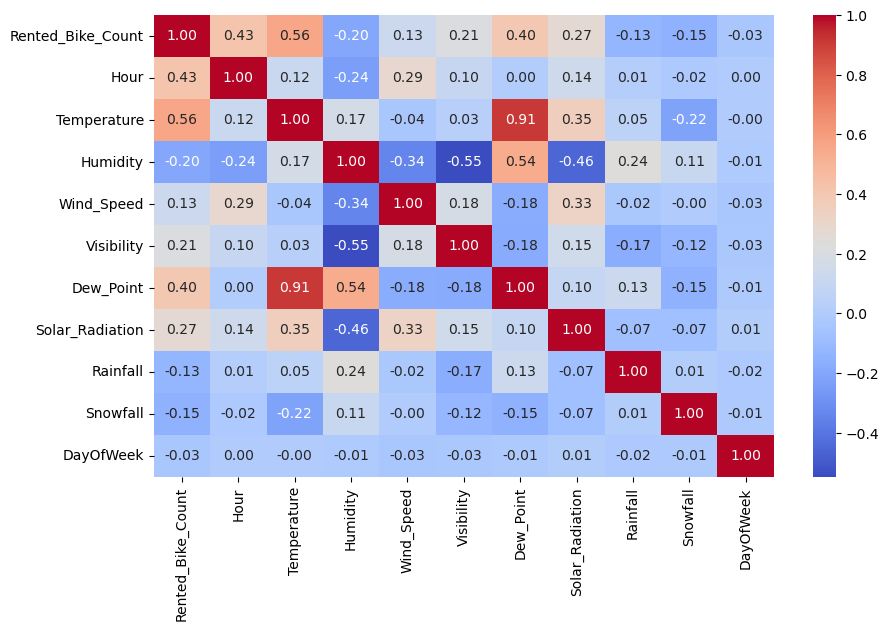

In [29]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.show()

 ### 3. CREATE THE 4 EXPERIMENTAL DATABASES

----

### DATABASE 1: Baseline Data (Minimal Processing)
#### (No custom weather, no cyclical dates, no scaling)

In [30]:
df1 = df.copy()
# Convert text categories to 1s and 0s
df1['Holiday'] = df1['Holiday'].map({'Holiday': 1, 'No Holiday': 0})

df1 = pd.get_dummies(df1, columns=['Seasons'], drop_first=False, dtype=int)

df1 = df1.drop(['Weather_Condition','Dew_Point', 'Seasons_Winter'], axis=1) #month, day of week to stay 

df1.rename(columns= {'Seasons_Autumn':'Autumn', 'Seasons_Spring': 'Spring', 'Seasons_Summer': 'Summer'}, inplace=True) #better to drop winter than autumn

In [31]:
output_folder = 'data/processed'
os.makedirs(output_folder, exist_ok=True)

# 2. Define the exact file path and name
file_path = f"{output_folder}/df1_baseline.csv"

# 3. Export df1 to CSV
# index=False prevents pandas from saving the row numbers as a useless extra column
df1.to_csv(file_path, index=False)

print(f"Successfully exported df1 to: {file_path}")

Successfully exported df1 to: data/processed/df1_baseline.csv


In [32]:
df1.head()

,Rented_Bike_Count,Hour,Temperature,Humidity,Wind_Speed,Visibility,Solar_Radiation,Rainfall,Snowfall,Holiday,DayOfWeek,Autumn,Spring,Summer
0,254,0,-5.2,37,2.2,2000,0.0,0.0,0.0,0,4,0,0,0
1,204,1,-5.5,38,0.8,2000,0.0,0.0,0.0,0,4,0,0,0
2,173,2,-6.0,39,1.0,2000,0.0,0.0,0.0,0,4,0,0,0
3,107,3,-6.2,40,0.9,2000,0.0,0.0,0.0,0,4,0,0,0
4,78,4,-6.0,36,2.3,2000,0.0,0.0,0.0,0,4,0,0,0


In [33]:
df1

,Rented_Bike_Count,Hour,Temperature,Humidity,Wind_Speed,Visibility,Solar_Radiation,Rainfall,Snowfall,Holiday,DayOfWeek,Autumn,Spring,Summer
0,254,0,-5.2,37,2.2,2000,0.0,0.0,0.0,0,4,0,0,0
1,204,1,-5.5,38,0.8,2000,0.0,0.0,0.0,0,4,0,0,0
2,173,2,-6.0,39,1.0,2000,0.0,0.0,0.0,0,4,0,0,0
3,107,3,-6.2,40,0.9,2000,0.0,0.0,0.0,0,4,0,0,0
4,78,4,-6.0,36,2.3,2000,0.0,0.0,0.0,0,4,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8755,1003,19,4.2,34,2.6,1894,0.0,0.0,0.0,0,4,1,0,0
8756,764,20,3.4,37,2.3,2000,0.0,0.0,0.0,0,4,1,0,0
8757,694,21,2.6,39,0.3,1968,0.0,0.0,0.0,0,4,1,0,0
8758,712,22,2.1,41,1.0,1859,0.0,0.0,0.0,0,4,1,0,0


### Check correlation heatmap

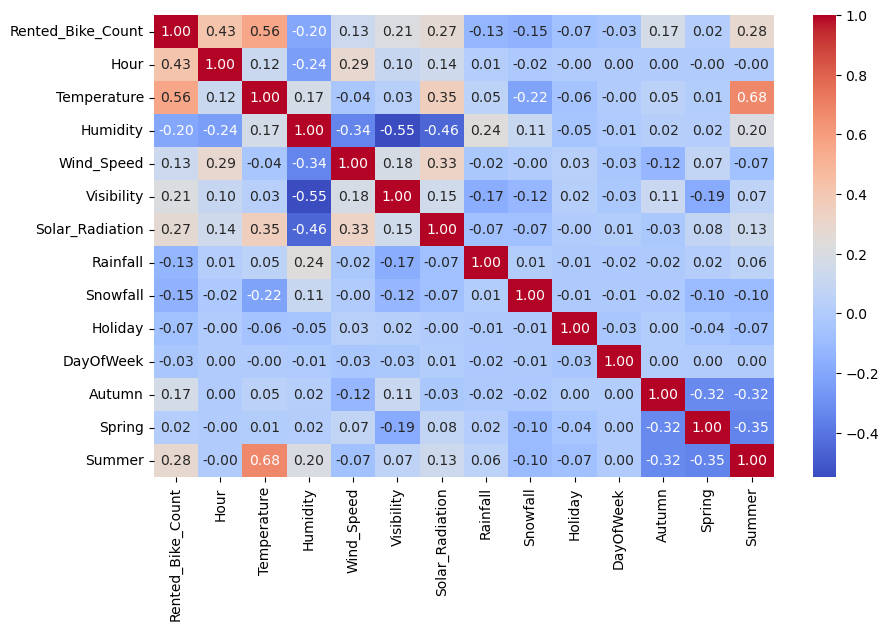

In [34]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df1.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.show()

---

 ### DATABASE 2: Tree Data (Custom Weather + Cyclical Dates, UNSCALED)

In [35]:

df2 = df.copy()

# 1. FIX THE HOLIDAY COLUMN
# Manually map it so 1 = Holiday and 0 = Regular day. 
# (We do this BEFORE get_dummies so pandas leaves it alone!)
df2['Holiday'] = df2['Holiday'].map({'Holiday': 1, 'No Holiday': 0})

# 2. CREATE DUMMIES (Notice we removed 'Holiday' from this list)
df2 = pd.get_dummies(df2, columns=['Seasons'], drop_first=False, dtype=int)

df2.rename(columns= {'Seasons_Autumn':'Autumn', 'Seasons_Spring': 'Spring', 'Seasons_Summer': 'Summer', 'Seasons_Winter': 'Winter'}, inplace=True)

# 3. CREATE CYCLICAL DATES #removal of months since there is an existing collinearity with the seasons features 
df2['DayOfWeek_sin'] = np.sin(2 * np.pi * df2['DayOfWeek'] / 7)
df2['DayOfWeek_cos'] = np.cos(2 * np.pi * df2['DayOfWeek'] / 7)
df2['Hour_sin'] = np.sin(2 * np.pi * df2['Hour'] / 24)
df2['Hour_cos'] = np.cos(2 * np.pi * df2['Hour'] / 24)
# ==========================================
# 4. THE "KEEP LIST" (Modify this list to match your screenshot!)
# ==========================================
columns_to_keep = [
    'Rented_Bike_Count', 
    'Hour', 
    'Temperature', 
    'Humidity', 
    'Wind_Speed', 
    'Visibility', 
    'Solar_Radiation',
    'Holiday',                 
    'DayOfWeek_sin', 'DayOfWeek_cos',
    'Spring', 'Summer', 'Autumn'
]

# Force df2 to ONLY contain the columns in our Keep List
df2 = df2[columns_to_keep]

In [36]:
output_folder = 'data/processed'
os.makedirs(output_folder, exist_ok=True)

# 2. Define the exact file path and name
file_path = f"{output_folder}/df2_decisiontree.csv"

# 3. Export df1 to CSV
# index=False prevents pandas from saving the row numbers as a useless extra column
df2.to_csv(file_path, index=False)

print(f"Successfully exported df2 to: {file_path}")

Successfully exported df2 to: data/processed/df2_decisiontree.csv


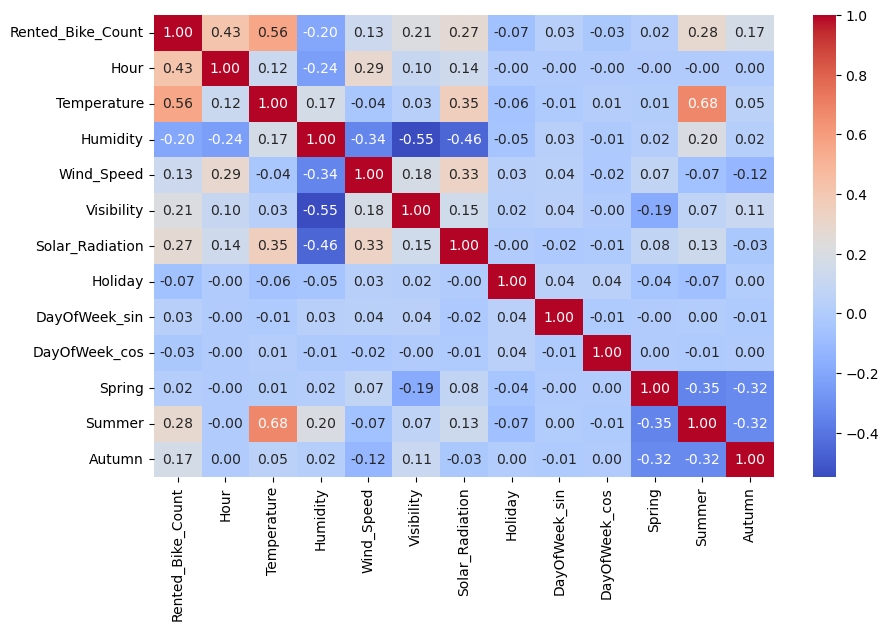

In [37]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df2.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.show()

In [38]:
df2.head(10)

,Rented_Bike_Count,Hour,Temperature,Humidity,Wind_Speed,Visibility,Solar_Radiation,Holiday,DayOfWeek_sin,DayOfWeek_cos,Spring,Summer,Autumn
0,254,0,-5.2,37,2.2,2000,0.00,0,-0.433884,-0.900969,0,0,0
1,204,1,-5.5,38,0.8,2000,0.00,0,-0.433884,-0.900969,0,0,0
2,173,2,-6.0,39,1.0,2000,0.00,0,-0.433884,-0.900969,0,0,0
3,107,3,-6.2,40,0.9,2000,0.00,0,-0.433884,-0.900969,0,0,0
4,78,4,-6.0,36,2.3,2000,0.00,0,-0.433884,-0.900969,0,0,0
5,100,5,-6.4,37,1.5,2000,0.00,0,-0.433884,-0.900969,0,0,0
6,181,6,-6.6,35,1.3,2000,0.00,0,-0.433884,-0.900969,0,0,0
7,460,7,-7.4,38,0.9,2000,0.00,0,-0.433884,-0.900969,0,0,0
8,930,8,-7.6,37,1.1,2000,0.01,0,-0.433884,-0.900969,0,0,0
9,490,9,-6.5,27,0.5,1928,0.23,0,-0.433884,-0.900969,0,0,0


-----------

In [39]:
import pandas as pd
import numpy as np
import plotly.express as px

# 1. Generate the 24 hours and calculate their Sin/Cos values
hours = np.arange(24)
hour_sin = np.sin(2 * np.pi * hours / 24)
hour_cos = np.cos(2 * np.pi * hours / 24)

df_cyclical = pd.DataFrame({
    'Hour': hours,
    'Sine (y-axis)': hour_sin,
    'Cosine (x-axis)': hour_cos
})

# 2. Your presentation colors
dark_green = '#3F7A4D'
tan_gold = '#D1AC71'

# 3. Create the circular Scatter Plot
fig = px.scatter(
    df_cyclical,
    x='Cosine (x-axis)',
    y='Sine (y-axis)',
    text='Hour', # Puts the actual hour number right next to the dot!
    title='<b>Cyclical Encoding: The 24-Hour Clock</b><br><sup>Proving to the model that Hour 23 and Hour 0 are neighbors</sup>'
)

# 4. Format the aesthetics
fig.update_traces(
    marker=dict(size=14, color=tan_gold, line=dict(width=2, color=dark_green)),
    textposition='top center',
    textfont=dict(size=14, color='#333333', family='Arial Black')
)

fig.update_layout(
    width=800,
    height=800, # Keeping it perfectly square so the circle doesn't stretch into an oval
    plot_bgcolor='white',
    paper_bgcolor='white',
    title_font=dict(size=22, color=dark_green),
    
    # Lock the axes so it stays a perfect circle
    xaxis=dict(range=[-1.5, 1.5], showgrid=True, gridcolor='#E0E0E0', zerolinecolor=dark_green),
    yaxis=dict(range=[-1.5, 1.5], showgrid=True, gridcolor='#E0E0E0', zerolinecolor=dark_green)
)

fig.show()

### DATABASE 3: Regression Data (Engineered + Cyclical, SCALED, Outliers removed)

---

In [40]:
df3 = df2.copy() # Start with the Database 2 structure

# Identify and remove extreme spikes in Bike Rentals using the IQR Boxplot math
Q1 = df3['Rented_Bike_Count'].quantile(0.25)
Q3 = df3['Rented_Bike_Count'].quantile(0.75)
IQR = Q3 - Q1
df3 = df3[(df3['Rented_Bike_Count'] >= (Q1 - 1.5 * IQR)) & (df3['Rented_Bike_Count'] <= (Q3 + 1.5 * IQR))]


In [41]:
output_folder = 'data/processed'
os.makedirs(output_folder, exist_ok=True)

# 2. Define the exact file path and name
file_path = f"{output_folder}/df3_regressiondata_removedoutliers.csv"

# 3. Export df1 to CSV
# index=False prevents pandas from saving the row numbers as a useless extra column
df3.to_csv(file_path, index=False)

print(f"Successfully exported df3 to: {file_path}")

Successfully exported df3 to: data/processed/df3_regressiondata_removedoutliers.csv


In [42]:
df3.head()

,Rented_Bike_Count,Hour,Temperature,Humidity,Wind_Speed,Visibility,Solar_Radiation,Holiday,DayOfWeek_sin,DayOfWeek_cos,Spring,Summer,Autumn
0,254,0,-5.2,37,2.2,2000,0.0,0,-0.433884,-0.900969,0,0,0
1,204,1,-5.5,38,0.8,2000,0.0,0,-0.433884,-0.900969,0,0,0
2,173,2,-6.0,39,1.0,2000,0.0,0,-0.433884,-0.900969,0,0,0
3,107,3,-6.2,40,0.9,2000,0.0,0,-0.433884,-0.900969,0,0,0
4,78,4,-6.0,36,2.3,2000,0.0,0,-0.433884,-0.900969,0,0,0


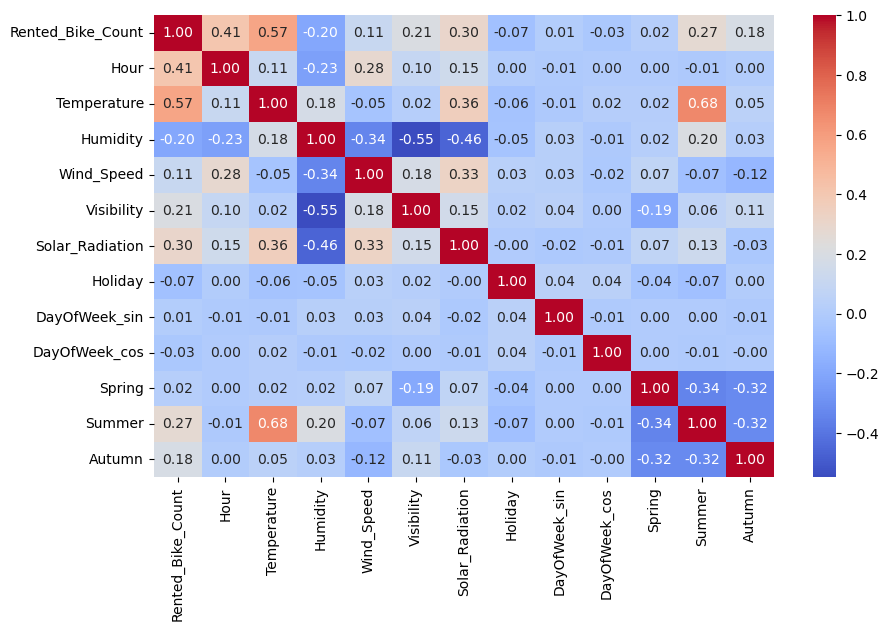

In [43]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df3.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.show()

### DATABASE 4: Weather Only (The Extreme Baseline)

In [44]:
df.columns

Index(['Rented_Bike_Count', 'Hour', 'Temperature', 'Humidity', 'Wind_Speed',
       'Visibility', 'Dew_Point', 'Solar_Radiation', 'Rainfall', 'Snowfall',
       'Seasons', 'Holiday', 'DayOfWeek', 'Weather_Condition'],
      dtype='object')

In [45]:
# Strip hidden spaces from all column names just in case!
df.columns = df.columns.str.strip()

df4 = df.copy()

# 1. Fix the Holiday column (1 = Holiday, 0 = Regular day)
df4['Holiday'] = df4['Holiday'].map({'Holiday': 1, 'No Holiday': 0})

# 2. Create Dummies for Categories
df4 = pd.get_dummies(df4, columns=['Seasons', 'Weather_Condition'], drop_first=False, dtype=int)

df4.rename(columns= {'Seasons_Autumn':'Autumn', 'Seasons_Spring': 'Spring', 'Seasons_Summer': 'Summer', 'Seasons_Winter': 'Winter'}, inplace=True)
# 3. Create Cyclical Dates and Hours
df4['DayOfWeek_sin'] = np.sin(2 * np.pi * df4['DayOfWeek'] / 7)
df4['DayOfWeek_cos'] = np.cos(2 * np.pi * df4['DayOfWeek'] / 7)
df4['Hour_sin'] = np.sin(2 * np.pi * df4['Hour'] / 24)
df4['Hour_cos'] = np.cos(2 * np.pi * df4['Hour'] / 24)

# 4. Drop the old flat time numbers AND the specific weather variables you requested
columns_to_drop = [
    'DayOfWeek', 'Hour',     # The old flat time numbers
    'Humidity', 'Wind_Speed',         # The specific weather variables you requested
    'Snowfall', 'Rainfall', 
    'Dew_Point', 'Winter', 'Solar_Radiation', 'Visibility'                      # (Dropped to prevent multicollinearity with Temperature)
]
df4 = df4.drop(columns=columns_to_drop)

In [46]:
output_folder = 'data/processed'
os.makedirs(output_folder, exist_ok=True)

# 2. Define the exact file path and name
file_path = f"{output_folder}/df4_weather_condition.csv"

# 3. Export df1 to CSV
# index=False prevents pandas from saving the row numbers as a useless extra column
df4.to_csv(file_path, index=False)

print(f"Successfully exported df4 to: {file_path}")

Successfully exported df4 to: data/processed/df4_weather_condition.csv


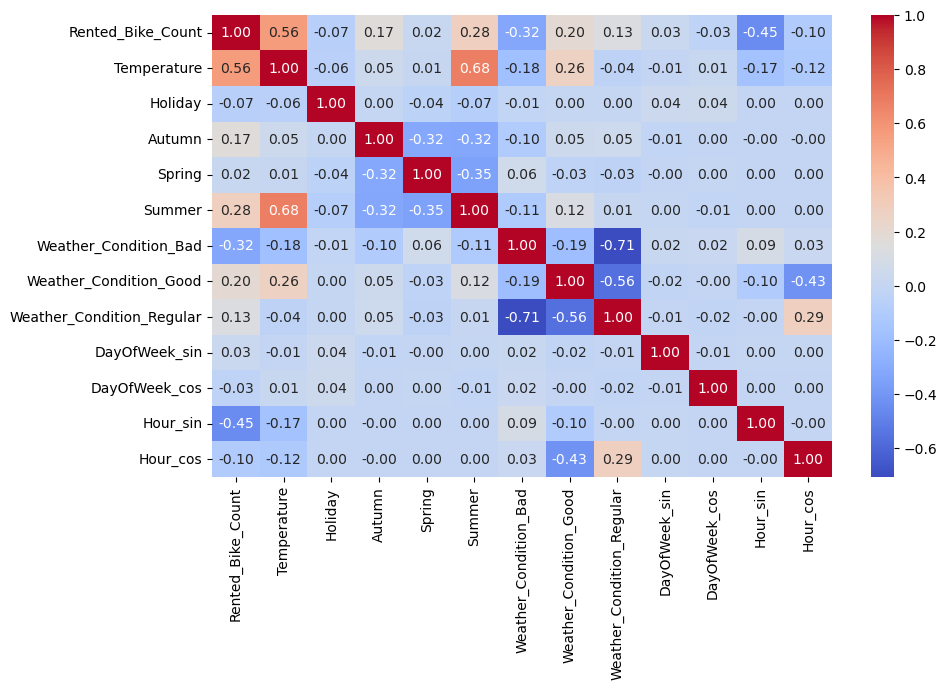

In [47]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df4.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.show()

In [48]:
df4.head()

,Rented_Bike_Count,Temperature,Holiday,Autumn,Spring,Summer,Weather_Condition_Bad,Weather_Condition_Good,Weather_Condition_Regular,DayOfWeek_sin,DayOfWeek_cos,Hour_sin,Hour_cos
0,254,-5.2,0,0,0,0,0,0,1,-0.433884,-0.900969,0.000000,1.000000
1,204,-5.5,0,0,0,0,0,0,1,-0.433884,-0.900969,0.258819,0.965926
2,173,-6.0,0,0,0,0,0,0,1,-0.433884,-0.900969,0.500000,0.866025
3,107,-6.2,0,0,0,0,0,0,1,-0.433884,-0.900969,0.707107,0.707107
4,78,-6.0,0,0,0,0,0,0,1,-0.433884,-0.900969,0.866025,0.500000
